In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.gaussian_process.kernels import RBF
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import sigmoid_kernel
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures


In [20]:
cdf = pd.read_csv('./china_gdp.csv')


In [21]:
mask = np.random.rand(len(cdf)) < 0.8
train = cdf[mask]
test = cdf[~mask]

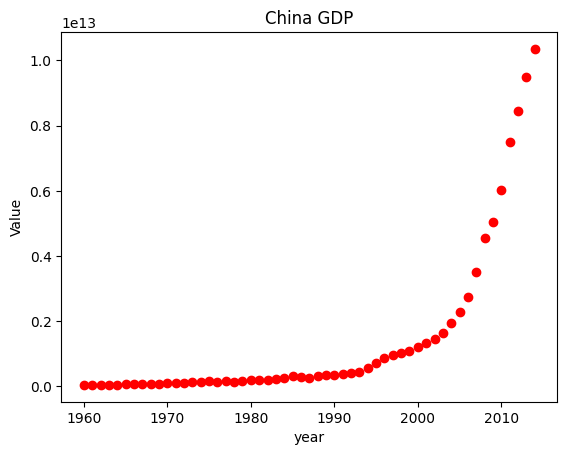

In [22]:
plt.plot(cdf['Year'],cdf['Value'], 'ro')
plt.xlabel('year')
plt.ylabel('Value')
plt.title('China GDP')
plt.show()

In [23]:
poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(np.asanyarray(cdf[['Year']]))

In [24]:
def sigmoid(x, b_1, b_2):
    return 1/(1+np.exp(-b_1*(x-b_2)))

In [25]:
x = np.asanyarray(cdf['Year']/max(cdf['Year']))
y = np.asanyarray(cdf['Value']/max(cdf['Value']))

p1 , p2 = curve_fit(sigmoid, x, y)
print(p1 , p2)

[690.45170921   0.99720713] [[ 1.52271497e+03 -2.88118980e-04]
 [-2.88118980e-04  7.25961452e-09]]


In [26]:
x_ = np.arange(1960, 2024)
x_ = (x_/2014)

y_ = sigmoid(x_,p1[0],p1[1])

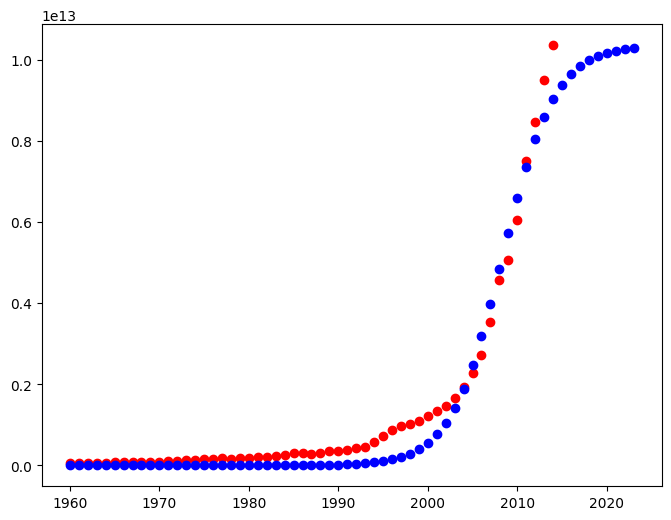

In [27]:
plt.figure(figsize=(8,6))


y_ = sigmoid(x_, p1[0], p1[1])

plt.plot(x*2014,y*10354831729340.4, 'ro')


plt.plot(x_* 2014, y_*10354831729340.4, 'bo')
